# Setup

In [1]:
!pip install -q transformers gensim

import re
import collections
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Word-Level Tokenization (OOV problem)

In [2]:
review = "This book kept me up all night - totally unputdownable"

#naive word-level tokenization
word_tokens = review.lower().replace("-", "").replace("!", "").split(" ")
print(word_tokens)

['this', 'book', 'kept', 'me', 'up', 'all', 'night', '', 'totally', 'unputdownable']


In [3]:
# how much your model will know,
# this depends on entire dataset.

vocab = {"this": 0, "book": 1, "kept": 2, "me": 3, "up": 4, "all": 5, "night": 6, "totally": 7}
vocab

{'this': 0,
 'book': 1,
 'kept': 2,
 'me': 3,
 'up': 4,
 'all': 5,
 'night': 6,
 'totally': 7}

In [6]:
ids = [vocab.get(tok, -1) for tok in word_tokens] # -1 stands in for <UNK>
print(ids)

[0, 1, 2, 3, 4, 5, 6, -1, 7, -1]


# Example

In [7]:
sentence = "The plot twist blew my mind!"
tokens = sentence.lower().replace("!", "").split()
print(tokens)
print([vocab.get(tok, -1) for tok in tokens])

['the', 'plot', 'twist', 'blew', 'my', 'mind']
[-1, -1, -1, -1, -1, -1]


# Byte-Pair Encoding

In [9]:
from transformers import GPT2Tokenizer

bpe_tokenizer = GPT2Tokenizer.from_pretrained("gpt2") # 2020

sentence = "This book was unputdownable and utterly captivating."

print("BPE (GPT-2):     ", bpe_tokenizer.tokenize(sentence))

BPE (GPT-2):      ['This', 'Ġbook', 'Ġwas', 'Ġun', 'put', 'down', 'able', 'Ġand', 'Ġutterly', 'Ġcapt', 'ivating', '.']


# WordPiece Tokenizer - BERT model

In [11]:
from transformers import BertTokenizer

wordpiece_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

print("WordPiece (BERT): ", wordpiece_tokenizer.tokenize(sentence))

WordPiece (BERT):  ['this', 'book', 'was', 'un', '##put', '##down', '##able', 'and', 'utterly', 'capt', '##ivating', '.']


# Example

In [12]:
sentence2 = "I asked Zylotech for a refund"
print("BPE (GPT-2):     ", bpe_tokenizer.tokenize(sentence2))
print("WordPiece (BERT): ", wordpiece_tokenizer.tokenize(sentence2))

BPE (GPT-2):      ['I', 'Ġasked', 'ĠZ', 'yl', 'otech', 'Ġfor', 'Ġa', 'Ġrefund']
WordPiece (BERT):  ['i', 'asked', 'z', '##yl', '##ote', '##ch', 'for', 'a', 'ref', '##und']


# Word2Vec

In [13]:
from gensim.models import Word2Vec

# Toy corpus of "reviews" (already tokenized into lowercase words)
reviews = [
    "this book kept me up all night it was so good".split(),
    "the plot twist blew my mind absolutely brilliant".split(),
    "boring book i almost fell asleep reading it".split(),
    "the mystery kept me guessing until the very end".split(),
    "the ending was predictable and honestly quite boring".split(),
    "brilliant characters and a gripping plot throughout".split(),
    "i could not put this book down it was gripping".split(),
]

model = Word2Vec(
    sentences=reviews,
    vector_size=50,   # dimensionality of each word vector
    window=2,          # how many neighboring words count as "context"
    min_count=1,        # keep even rare words for this tiny demo
    sg=1,                # sg=1 -> Skip-gram, sg=0 -> CBOW
    epochs=200,
)

In [14]:
model.wv

In [17]:
model.wv['gripping']  #word gripping in 50 dimesions

array([-0.0093056 ,  0.01001705, -0.01113353,  0.00610174,  0.00811732,
        0.009136  ,  0.01068291,  0.02038326, -0.03946117,  0.0056218 ,
       -0.01117492, -0.02531192,  0.03723491,  0.00177458,  0.01055829,
        0.00133532,  0.03547882,  0.04707108, -0.04496187, -0.04835492,
       -0.00505999,  0.00664914,  0.02326781, -0.01265547,  0.02837154,
        0.00847155,  0.01865246,  0.02233727, -0.02587591,  0.00528369,
        0.01105741, -0.03548636, -0.0033032 , -0.01383698, -0.03093695,
        0.00035013,  0.017388  ,  0.00182003,  0.004889  , -0.0104075 ,
        0.01397239,  0.00174077, -0.00803767,  0.03453857,  0.03404271,
        0.01145037, -0.00439764, -0.02802488,  0.00191273,  0.01188293],
      dtype=float32)

In [18]:
print("Vector for 'gripping' (first 10 dims):", model.wv["gripping"][:10])

Vector for 'gripping' (first 10 dims): [-0.0093056   0.01001705 -0.01113353  0.00610174  0.00811732  0.009136
  0.01068291  0.02038326 -0.03946117  0.0056218 ]


In [19]:
print("\nWords most similar to 'boring':")
for word, score in model.wv.most_similar("boring", topn=5):
    print(f"  {word}: {score:.3f}")


Words most similar to 'boring':
  kept: 0.648
  book: 0.640
  the: 0.640
  gripping: 0.639
  night: 0.634


# Pretrained GloVe Embeddings

In [22]:
import gensim.downloader as api

# Downloads a real pretrained GloVe model (50-dim, trained on Wikipedia + Gigaword)
glove_vectors = api.load("glove-wiki-gigaword-50")

In [23]:
np.dot(glove_vectors['man'], glove_vectors['woman'])

np.float32(25.906172)

In [24]:
np.dot(glove_vectors['man'], glove_vectors['banana'])

np.float32(5.1393065)

In [25]:
print(glove_vectors['man'])
print()
print(glove_vectors['king'])
print()
print(glove_vectors['apple'])
print()
print(glove_vectors['paris'])

[-0.094386  0.43007  -0.17224  -0.45529   1.6447    0.40335  -0.37263
  0.25071  -0.10588   0.10778  -0.10848   0.15181  -0.65396   0.55054
  0.59591  -0.46278   0.11847   0.64448  -0.70948   0.23947  -0.82905
  1.272     0.033021  0.2935    0.3911   -2.8094   -0.70745   0.4106
  0.3894   -0.2913    2.6124   -0.34576  -0.16832   0.25154   0.31216
  0.31639   0.12539  -0.012646  0.22297  -0.56585  -0.086264  0.62549
 -0.0576    0.29375   0.66005  -0.53115  -0.48233  -0.97925   0.53135
 -0.11725 ]

[ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012  -0.076666  1.493    -0.034189 -0.98173
  0.68229   0.81722  -0.51874  -0.31503  -0.55809   0.66421   0.1961
 -0.13495  -0.11476  -0.30344   0.41177  -2.223    -1.0756   -1.0783
 -0.34354   0.33505   1.9927   -0.04234  -0.64319   0.71125   0.49159
  0.16754   0.34344  -0.25663  -0.8523    0.1661    0.40102   1.1685
 -1.0137   -0.21585  -0.15155   0.78321  -0.91241  -1.6106   -0.64426
 -0.51042 ]

In [26]:
# The famous analogy: king - man + woman ≈ ?
result = glove_vectors.most_similar(positive=["king", "woman"], negative=["man"], topn=3)
print("king - man + woman ≈", result)

king - man + woman ≈ [('queen', 0.8523604273796082), ('throne', 0.7664334177970886), ('prince', 0.7592144012451172)]


In [27]:
print("\nMost similar to 'terrific':")
print(glove_vectors.most_similar("terrific", topn=5))


Most similar to 'terrific':
[('wonderful', 0.8498780131340027), ('amazing', 0.8482187390327454), ('exciting', 0.8192530274391174), ('fun', 0.8187724351882935), ('fantastic', 0.813235342502594)]


# Example

In [28]:
print(glove_vectors.most_similar(positive=["paris", "italy"], negative=["france"], topn=3))

[('rome', 0.8465589284896851), ('milan', 0.7766007781028748), ('turin', 0.766635537147522)]


# Visualizing the embedding space (PCA)

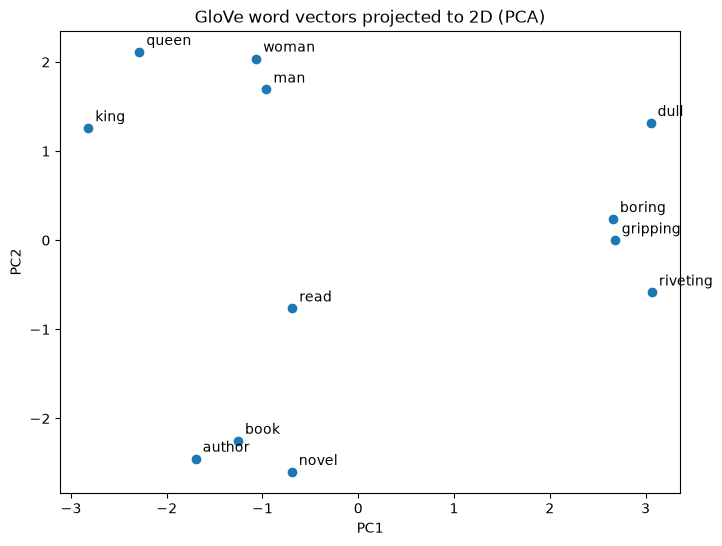

In [29]:
from sklearn.decomposition import PCA

words = ["king", "queen", "man", "woman", "book", "novel", "author", "read", "boring", "gripping", "riveting", "dull"]
vectors = np.array([glove_vectors[w] for w in words])

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1])
for word, (x, y) in zip(words, coords):
    plt.annotate(word, (x, y), textcoords="offset points", xytext=(5, 5))
plt.title("GloVe word vectors projected to 2D (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()